In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import seaborn as sns
from tabulate import tabulate

os.environ['PATH'] += ':/Library/TeX/texbin'

plt.rcParams.update({
    "text.usetex": True,
})

In [23]:
results_paths: dict = {
    "ablation_dense": "../data/exp2_ablation_dense.csv",
    "ablation_sparse": "../data/exp2_ablation_sparse.csv",
    "toysim": "../data/exp2_toysim.csv",
}

In [24]:
data_frames = {key: pd.read_csv(path) for key, path in results_paths.items()}

for key, df in data_frames.items():
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df = df.loc[:, (df.nunique() > 1)]
    print(f"Data Frame Head for {key}")
    print(tabulate(df.head(), headers='keys', tablefmt='psql'))
    
    # Print unique values in each column, excluding 'test_auc' and 'test_nll'
    exclude_cols = ['test_auc', 'test_nll']
    for col in df.columns:
        if len(df[col].unique()) > 1 and col not in exclude_cols:  
            print(f"Unique Values in Column '{col}':")
            unique_values = pd.DataFrame({'Value': df[col].unique()})
            print(tabulate(unique_values, headers='keys', tablefmt='psql'))

    data_frames[key] = df

Data Frame Head for ablation_dense
+----+------------+------------+-------------+-------------------+-----------------------+-------------------------+
|    |   test_nll |   test_auc |   num_tiles |   axis_resolution |   vector_length_scale |   vector_dimensionality |
|----+------------+------------+-------------+-------------------+-----------------------+-------------------------|
|  0 |   0.208333 |   0.987646 |           1 |               0.1 |                   0.1 |                   32768 |
|  1 |   0.187242 |   0.990342 |           2 |               0.1 |                   0.1 |                   32768 |
|  2 |   0.222224 |   0.985254 |           4 |               0.1 |                   0.1 |                   32768 |
|  3 |   0.18605  |   0.990933 |           8 |               0.1 |                   0.1 |                   32768 |
|  4 |   0.128498 |   0.992881 |           1 |               0.1 |                   0.2 |                   32768 |
+----+------------+----------

---
## Plot a correlation map for each dataframe
---

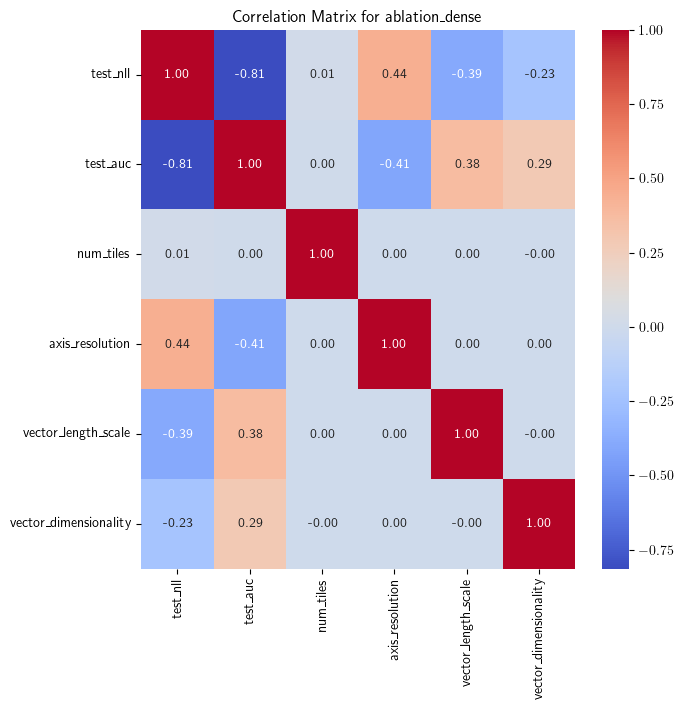

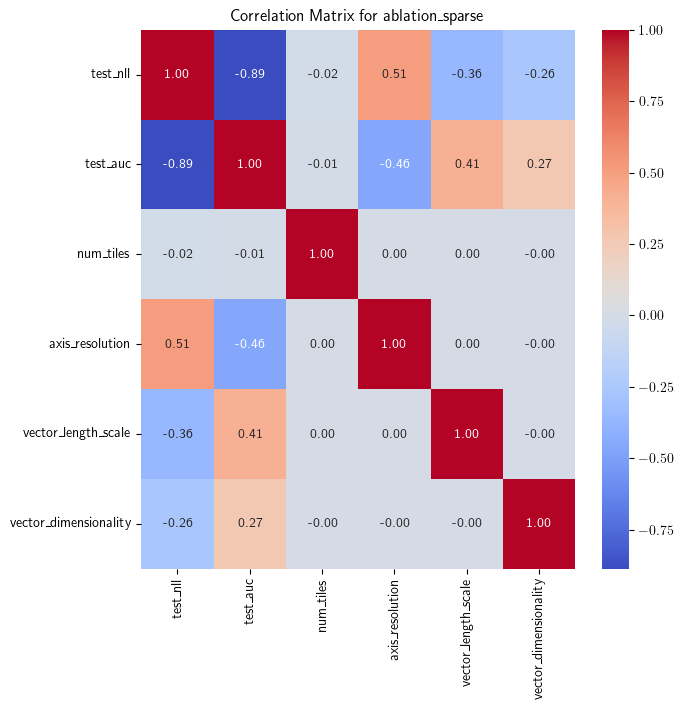

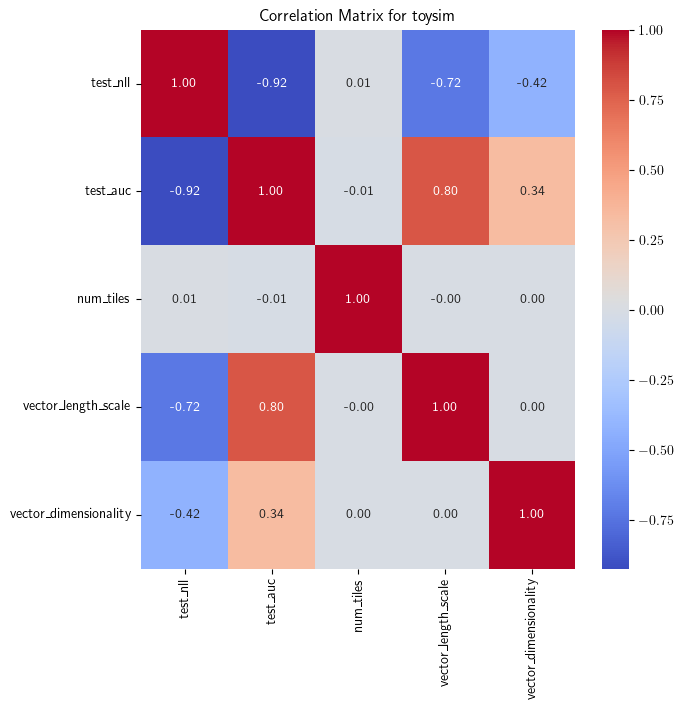

In [25]:
for key, df in data_frames.items():
    corr_matrix = df.corr()
    plt.figure(figsize=(7, 7))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title(f"Correlation Matrix for {key}")
    plt.savefig(f"exp2_correlation_matrix_{key}.svg")

---
### Vector Dimensionality versus AUC and NLL
---

In [26]:
# Extract statistics for each dataset

for key, df in data_frames.items():

    summary_stats = []

    grouped = df.groupby("vector_dimensionality")["test_auc"].describe(
        percentiles=[0.25, 0.5, 0.75]
    )
    
    for dim, row in grouped.iterrows():
        summary_stats.append([
            key,                  # Dataset Name
            dim,                  # Vector Dimensionality
            row["min"],           # Minimum
            row["25%"],           # Q1 (25th percentile)
            row["50%"],           # Median (50th percentile)
            row["75%"],           # Q3 (75th percentile)
            row["max"],           # Maximum
            row["mean"],          # Mean
            row["std"]            # Standard Deviation
        ])

    # Print results in a table format
    headers = ["Dataset", "Vector Dim", "Min", "Q1", "Median", "Q3", "Max", "Mean", "Std Dev"]
    print(tabulate(summary_stats, headers=headers, tablefmt="grid"))

+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| Dataset        |   Vector Dim |      Min |       Q1 |   Median |       Q3 |      Max |     Mean |   Std Dev |
+================+==============+==========+==========+==========+==========+==========+==========+===========+
| ablation_dense |          256 | 0.241738 | 0.609032 | 0.784931 | 0.897036 | 0.955736 | 0.744233 | 0.175125  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| ablation_dense |          512 | 0.350417 | 0.707988 | 0.823616 | 0.914989 | 0.97272  | 0.787234 | 0.154219  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| ablation_dense |         1024 | 0.282571 | 0.728847 | 0.875195 | 0.936456 | 0.983768 | 0.81164  | 0.166473  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----

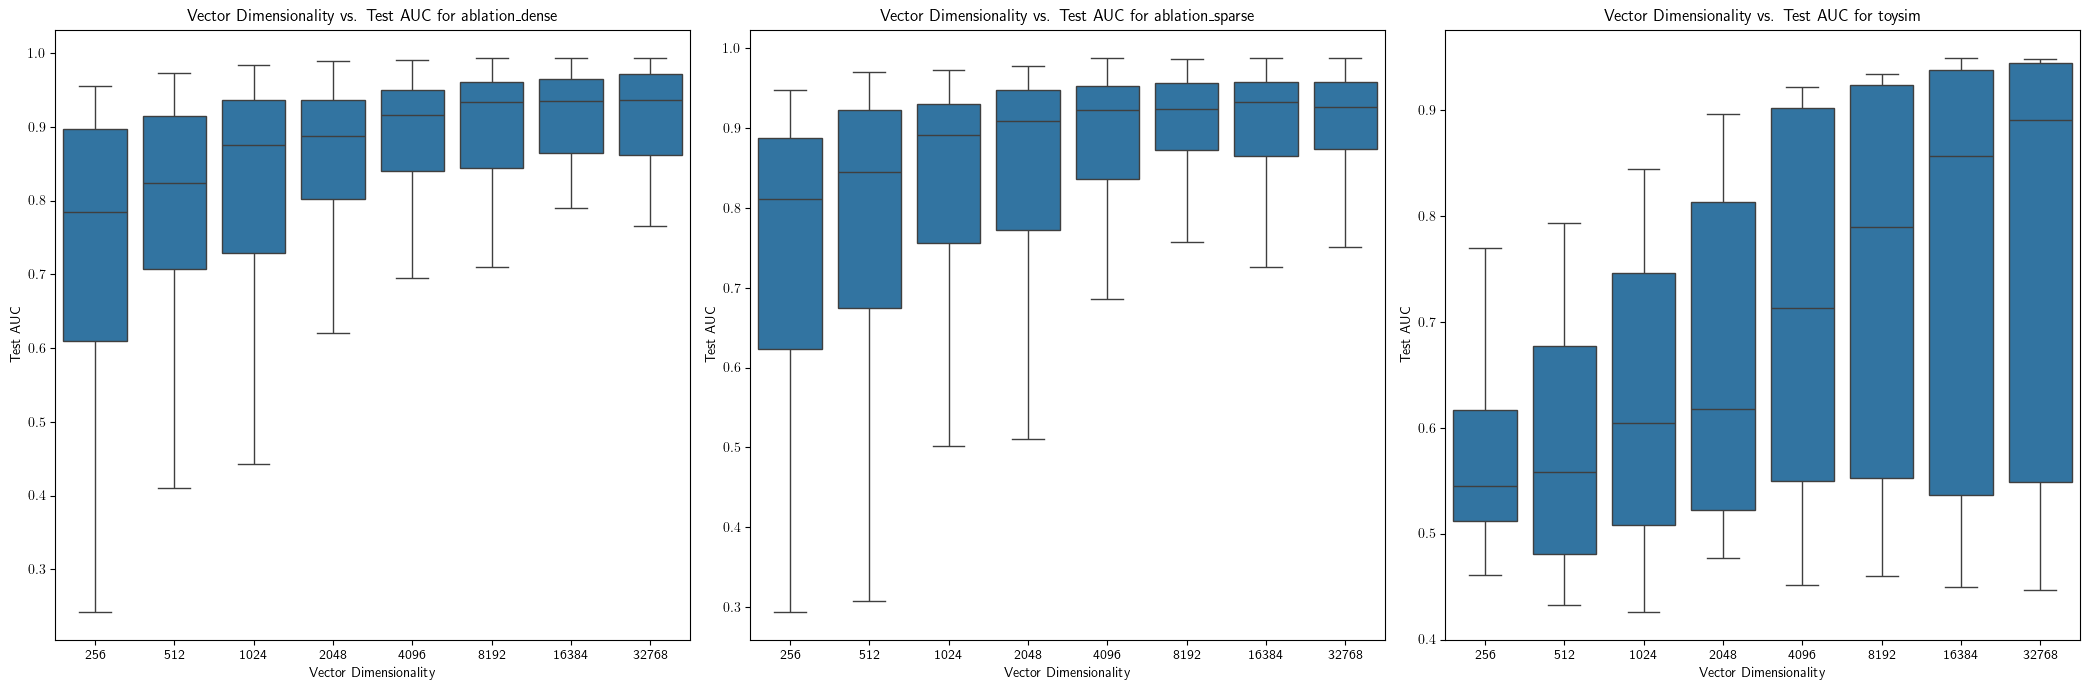

In [27]:
# create a box plot of vector dimensionality vs. test_auc for each dataset
num_datasets: int = len(data_frames.keys())

fig, axs = plt.subplots(1, num_datasets, figsize=(7*num_datasets, 7))

for idx, (key, df) in enumerate(data_frames.items()):
    sns.boxplot(x='vector_dimensionality', y='test_auc', data=df, ax=axs[idx], showfliers=False)
    axs[idx].set_xlabel("Vector Dimensionality")
    axs[idx].set_ylabel("Test AUC")
    axs[idx].set_title(f"Vector Dimensionality vs. Test AUC for {key}")

plt.tight_layout()
plt.savefig(f"exp2_boxplot_vector_dim_vs_test_auc.svg")

In [28]:
# Extract statistics for each dataset


for key, df in data_frames.items():

    summary_stats = []

    grouped = df.groupby("vector_dimensionality")["test_nll"].describe(
        percentiles=[0.25, 0.5, 0.75]
    )
    
    for dim, row in grouped.iterrows():
        summary_stats.append([
            key,                  # Dataset Name
            dim,                  # Vector Dimensionality
            row["min"],           # Minimum
            row["25%"],           # Q1 (25th percentile)
            row["50%"],           # Median (50th percentile)
            row["75%"],           # Q3 (75th percentile)
            row["max"],           # Maximum
            row["mean"],          # Mean
            row["std"]            # Standard Deviation
        ])

    # Print results in a table format
    headers = ["Dataset", "Vector Dim", "Min", "Q1", "Median", "Q3", "Max", "Mean", "Std Dev"]
    print(tabulate(summary_stats, headers=headers, tablefmt="grid"))

+----------------+--------------+----------+----------+----------+----------+---------+----------+-----------+
| Dataset        |   Vector Dim |      Min |       Q1 |   Median |       Q3 |     Max |     Mean |   Std Dev |
+================+==============+==========+==========+==========+==========+=========+==========+===========+
| ablation_dense |          256 | 0.300461 | 0.444915 | 0.588876 | 0.711984 | 1.53617 | 0.633046 |  0.243872 |
+----------------+--------------+----------+----------+----------+----------+---------+----------+-----------+
| ablation_dense |          512 | 0.277231 | 0.429554 | 0.555555 | 0.685516 | 1.77986 | 0.577903 |  0.203875 |
+----------------+--------------+----------+----------+----------+----------+---------+----------+-----------+
| ablation_dense |         1024 | 0.210718 | 0.404014 | 0.499007 | 0.681802 | 1.62503 | 0.566899 |  0.241381 |
+----------------+--------------+----------+----------+----------+----------+---------+----------+-----------+
|

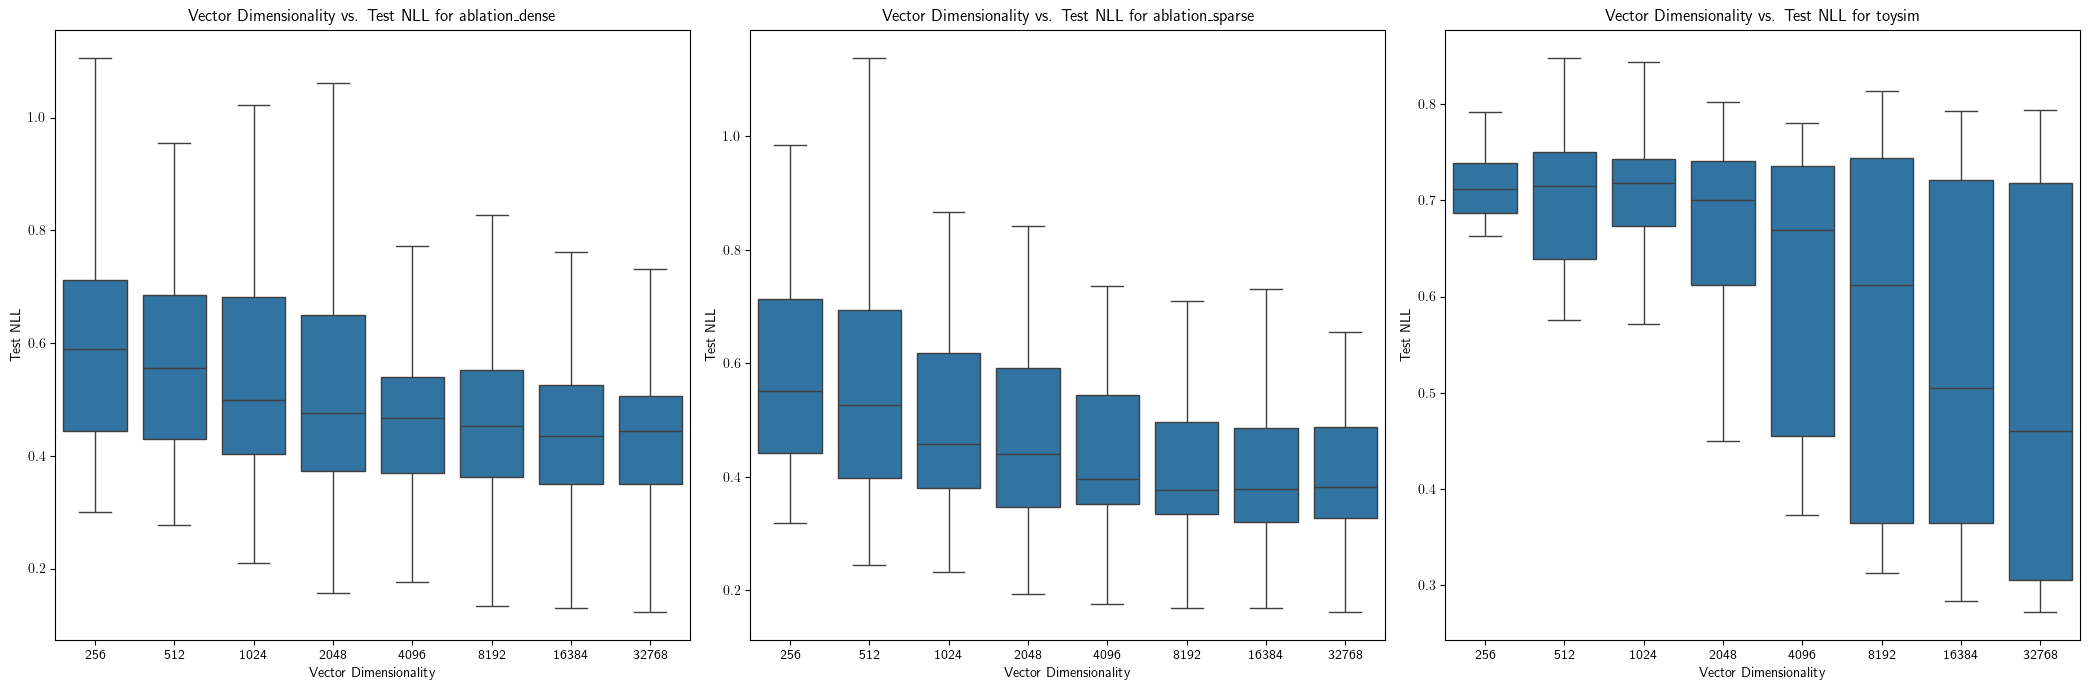

In [29]:
# create a box plot of vector dimensionality vs. test_nll for each dataset
num_datasets: int = len(data_frames.keys())

fig, axs = plt.subplots(1, num_datasets, figsize=(21, 7))

for idx, (key, df) in enumerate(data_frames.items()):
    sns.boxplot(x='vector_dimensionality', y='test_nll', data=df, ax=axs[idx], showfliers=False)
    axs[idx].set_xlabel("Vector Dimensionality")
    axs[idx].set_ylabel("Test NLL")
    axs[idx].set_title(f"Vector Dimensionality vs. Test NLL for {key}")

plt.tight_layout()
plt.savefig(f"exp2_boxplot_vector_dim_vs_test_nll.svg")

---
### Length Scale versus AUC and NLL
---

In [30]:
# Extract statistics for each dataset
for key, df in data_frames.items():

    summary_stats = []

    grouped = df.groupby("vector_length_scale")["test_auc"].describe(
        percentiles=[0.25, 0.5, 0.75]
    )
    
    for dim, row in grouped.iterrows():
        summary_stats.append([
            key,                  # Dataset Name
            dim,                  # Vector Dimensionality
            row["min"],           # Minimum
            row["25%"],           # Q1 (25th percentile)
            row["50%"],           # Median (50th percentile)
            row["75%"],           # Q3 (75th percentile)
            row["max"],           # Maximum
            row["mean"],          # Mean
            row["std"]            # Standard Deviation
        ])

    # Print results in a table format
    headers = ["Dataset", "Vector Dim", "Min", "Q1", "Median", "Q3", "Max", "Mean", "Std Dev"]
    print(tabulate(summary_stats, headers=headers, tablefmt="grid"))

+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| Dataset        |   Vector Dim |      Min |       Q1 |   Median |       Q3 |      Max |     Mean |   Std Dev |
+================+==============+==========+==========+==========+==========+==========+==========+===========+
| ablation_dense |          0.1 | 0.262452 | 0.561541 | 0.699297 | 0.840874 | 0.990933 | 0.699865 | 0.180809  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| ablation_dense |          0.2 | 0.259068 | 0.719829 | 0.831689 | 0.950721 | 0.993325 | 0.802161 | 0.167407  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| ablation_dense |          0.5 | 0.241738 | 0.832019 | 0.930844 | 0.974181 | 0.993952 | 0.878247 | 0.135132  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----

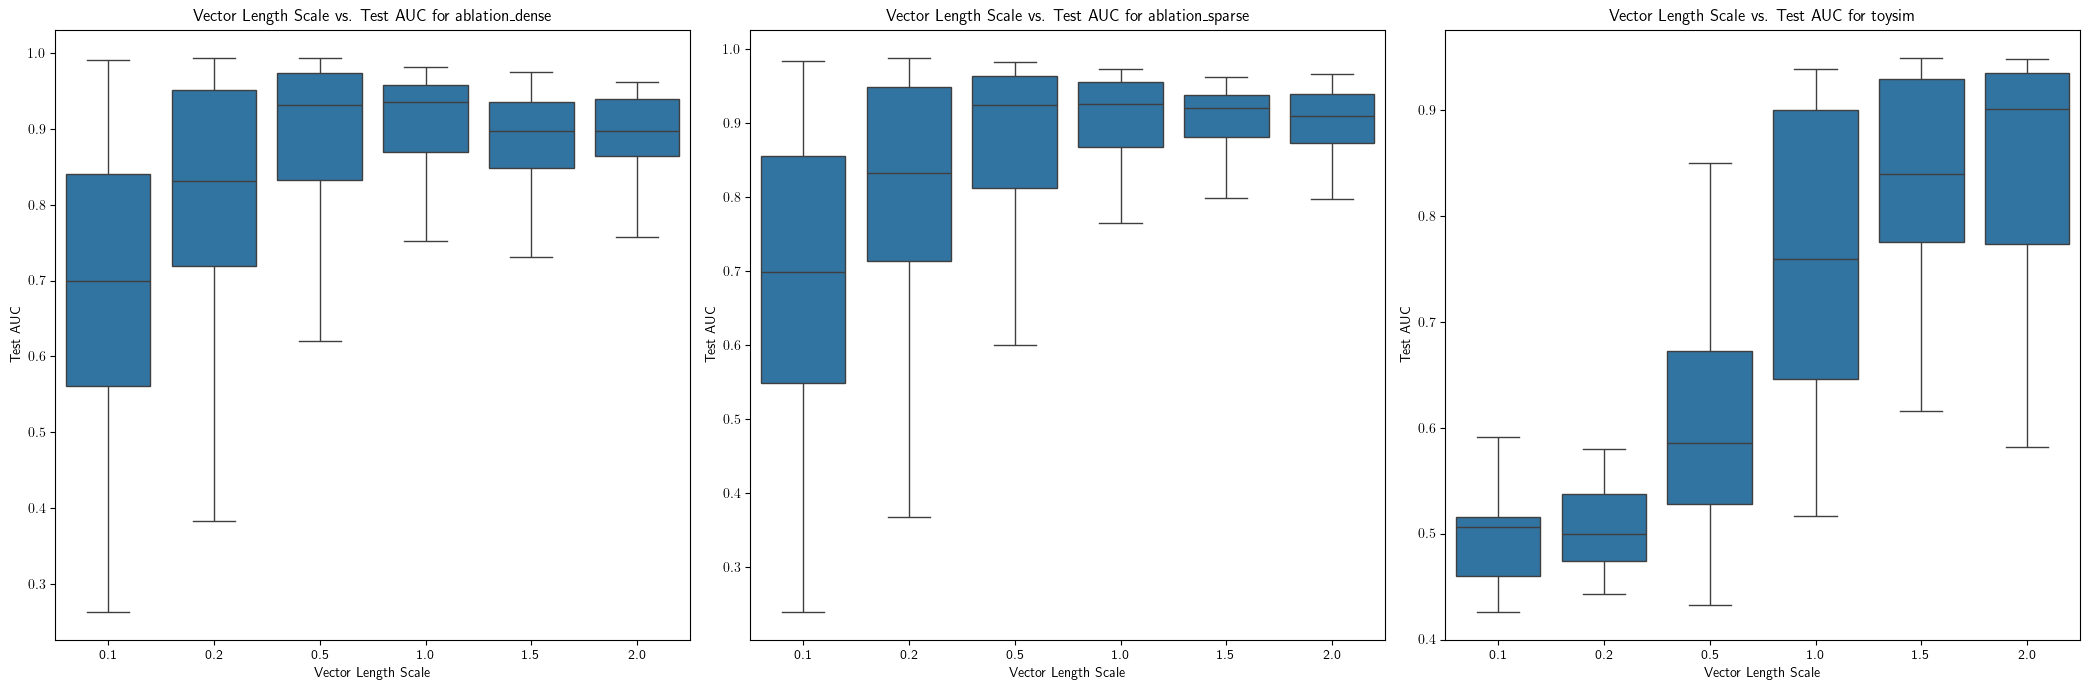

In [31]:
# create a box plot of vector length scale vs. test_auc for each dataset
num_datasets: int = len(data_frames.keys())

fig, axs = plt.subplots(1, num_datasets, figsize=(7*num_datasets, 7))

for idx, (key, df) in enumerate(data_frames.items()):
    sns.boxplot(x='vector_length_scale', y='test_auc', data=df, ax=axs[idx], showfliers=False)
    axs[idx].set_xlabel("Vector Length Scale")
    axs[idx].set_ylabel("Test AUC")
    axs[idx].set_title(f"Vector Length Scale vs. Test AUC for {key}")

plt.tight_layout()
plt.savefig(f"exp2_boxplot_vector_length_scale_vs_test_auc.svg")

In [32]:
# Extract statistics for each dataset
for key, df in data_frames.items():

    summary_stats = []

    grouped = df.groupby("vector_length_scale")["test_nll"].describe(
        percentiles=[0.25, 0.5, 0.75]
    )
    
    for dim, row in grouped.iterrows():
        summary_stats.append([
            key,                  # Dataset Name
            dim,                  # Vector Dimensionality
            row["min"],           # Minimum
            row["25%"],           # Q1 (25th percentile)
            row["50%"],           # Median (50th percentile)
            row["75%"],           # Q3 (75th percentile)
            row["max"],           # Maximum
            row["mean"],          # Mean
            row["std"]            # Standard Deviation
        ])

    # Print results in a table format
    headers = ["Dataset", "Vector Dim", "Min", "Q1", "Median", "Q3", "Max", "Mean", "Std Dev"]
    print(tabulate(summary_stats, headers=headers, tablefmt="grid"))

+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| Dataset        |   Vector Dim |      Min |       Q1 |   Median |       Q3 |      Max |     Mean |   Std Dev |
+================+==============+==========+==========+==========+==========+==========+==========+===========+
| ablation_dense |          0.1 | 0.18605  | 0.616479 | 0.716308 | 0.836873 | 1.77986  | 0.745818 | 0.283399  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| ablation_dense |          0.2 | 0.122271 | 0.485212 | 0.626489 | 0.759741 | 1.53617  | 0.629326 | 0.276073  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| ablation_dense |          0.5 | 0.126937 | 0.25678  | 0.479093 | 0.63557  | 1.4529   | 0.486039 | 0.257703  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----

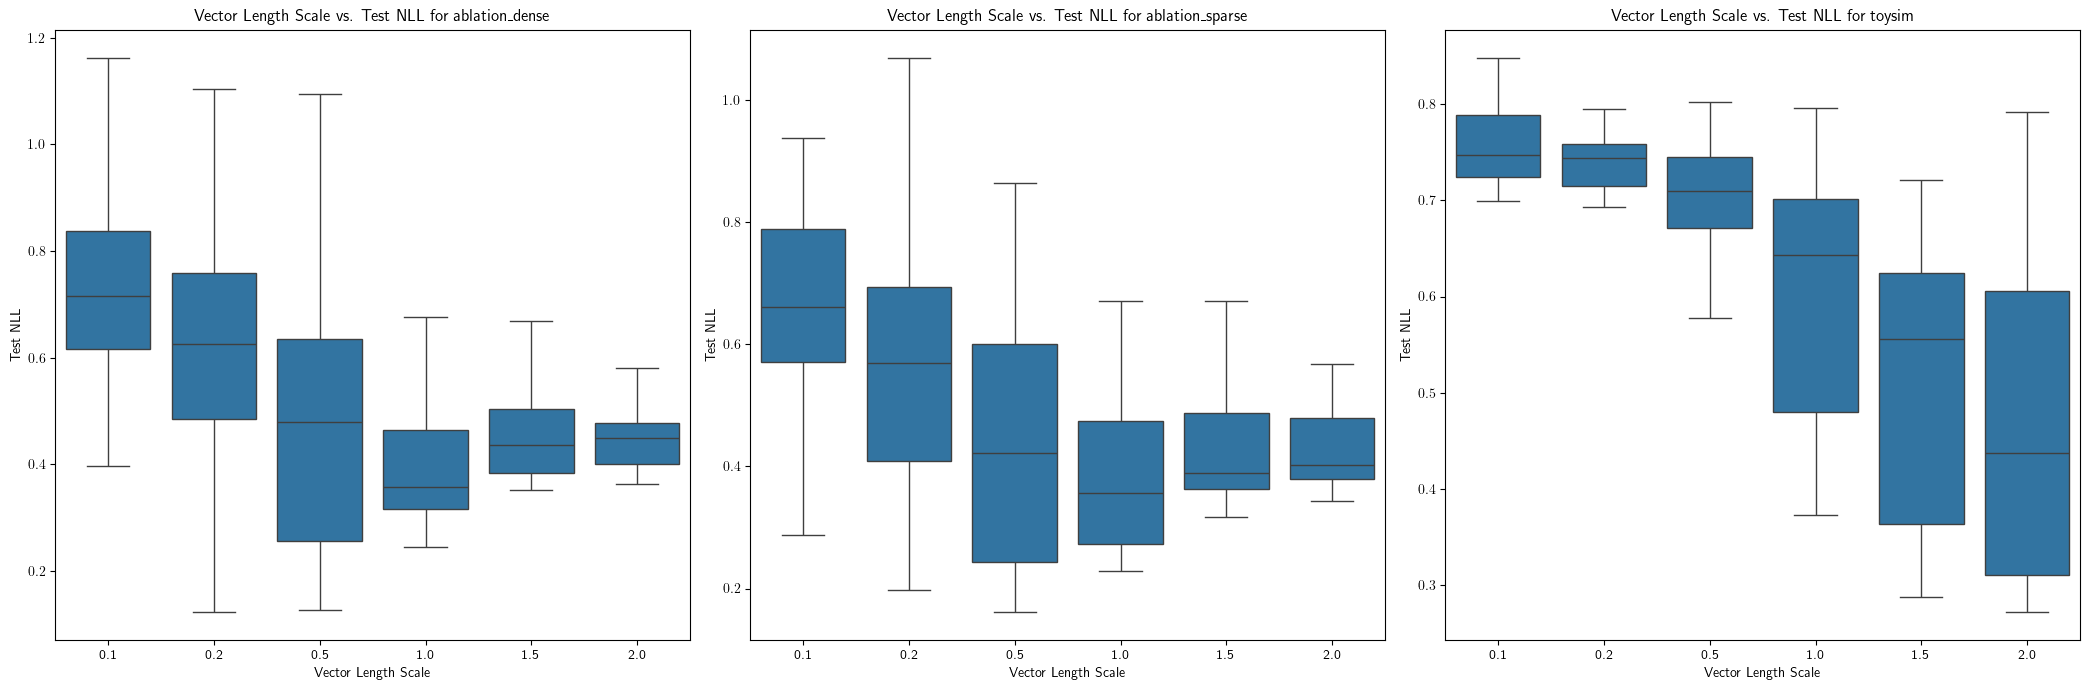

In [33]:
# create a box plot of vector length scale vs. test_nll for each dataset
num_datasets: int = len(data_frames.keys())

fig, axs = plt.subplots(1, num_datasets, figsize=(7*num_datasets, 7))

for idx, (key, df) in enumerate(data_frames.items()):
    sns.boxplot(x='vector_length_scale', y='test_nll', data=df, ax=axs[idx], showfliers=False)
    axs[idx].set_xlabel("Vector Length Scale")
    axs[idx].set_ylabel("Test NLL")
    axs[idx].set_title(f"Vector Length Scale vs. Test NLL for {key}")

plt.tight_layout()
plt.savefig(f"exp2_boxplot_vector_length_scale_vs_test_nll.svg")

---
### Axis Resolution versus AUC and NLL
---

In [34]:
# Extract statistics for each dataset
for key, df in data_frames.items():

    if key == "toysim":
        continue

    summary_stats = []

    grouped = df.groupby("axis_resolution")["test_auc"].describe(
        percentiles=[0.25, 0.5, 0.75]
    )
    
    for dim, row in grouped.iterrows():
        summary_stats.append([
            key,                  # Dataset Name
            dim,                  # Vector Dimensionality
            row["min"],           # Minimum
            row["25%"],           # Q1 (25th percentile)
            row["50%"],           # Median (50th percentile)
            row["75%"],           # Q3 (75th percentile)
            row["max"],           # Maximum
            row["mean"],          # Mean
            row["std"]            # Standard Deviation
        ])

    # Print results in a table format
    headers = ["Dataset", "Vector Dim", "Min", "Q1", "Median", "Q3", "Max", "Mean", "Std Dev"]
    print(tabulate(summary_stats, headers=headers, tablefmt="grid"))

+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| Dataset        |   Vector Dim |      Min |       Q1 |   Median |       Q3 |      Max |     Mean |   Std Dev |
+================+==============+==========+==========+==========+==========+==========+==========+===========+
| ablation_dense |         0.1  | 0.571331 | 0.858022 | 0.916119 | 0.97752  | 0.993952 | 0.901235 | 0.0869486 |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| ablation_dense |         0.25 | 0.445314 | 0.891939 | 0.948957 | 0.967054 | 0.981417 | 0.893849 | 0.128569  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| ablation_dense |         0.5  | 0.282571 | 0.790743 | 0.917716 | 0.934676 | 0.952433 | 0.836318 | 0.155185  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----

+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| Dataset        |   Vector Dim |      Min |       Q1 |   Median |       Q3 |      Max |     Mean |   Std Dev |
+================+==============+==========+==========+==========+==========+==========+==========+===========+
| ablation_dense |         0.1  | 0.122271 | 0.277902 | 0.428398 | 0.491892 | 0.709605 | 0.395555 |  0.152042 |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| ablation_dense |         0.25 | 0.224454 | 0.347096 | 0.405967 | 0.563561 | 0.907253 | 0.457018 |  0.17316  |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----------+
| ablation_dense |         0.5  | 0.331497 | 0.381246 | 0.477878 | 0.734183 | 1.24343  | 0.574776 |  0.222827 |
+----------------+--------------+----------+----------+----------+----------+----------+----------+-----

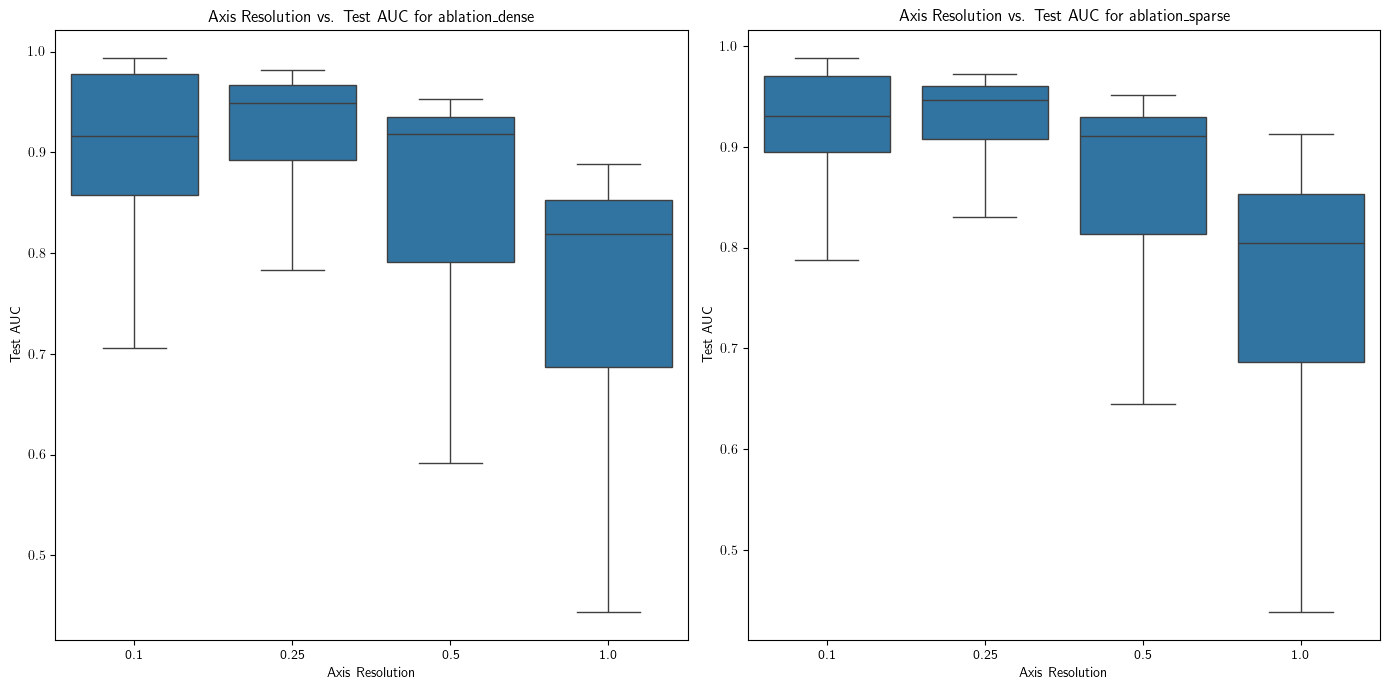

In [35]:
# Extract statistics for each dataset
for key, df in data_frames.items():

    if key == "toysim":
        continue

    summary_stats = []

    grouped = df.groupby("axis_resolution")["test_nll"].describe(
        percentiles=[0.25, 0.5, 0.75]
    )
    
    for dim, row in grouped.iterrows():
        summary_stats.append([
            key,                  # Dataset Name
            dim,                  # Vector Dimensionality
            row["min"],           # Minimum
            row["25%"],           # Q1 (25th percentile)
            row["50%"],           # Median (50th percentile)
            row["75%"],           # Q3 (75th percentile)
            row["max"],           # Maximum
            row["mean"],          # Mean
            row["std"]            # Standard Deviation
        ])

    # Print results in a table format
    headers = ["Dataset", "Vector Dim", "Min", "Q1", "Median", "Q3", "Max", "Mean", "Std Dev"]
    print(tabulate(summary_stats, headers=headers, tablefmt="grid"))

# create a box plot of axis resolution vs. test_auc for each dataset
num_datasets: int = len(data_frames.keys()) - 1

fig, axs = plt.subplots(1, num_datasets, figsize=(7*num_datasets, 7))

for idx, (key, df) in enumerate(data_frames.items()):
    if key == "toysim":
        continue
    sns.boxplot(x='axis_resolution', y='test_auc', data=df, ax=axs[idx], showfliers=False)
    axs[idx].set_xlabel("Axis Resolution")
    axs[idx].set_ylabel("Test AUC")
    axs[idx].set_title(f"Axis Resolution vs. Test AUC for {key}")

plt.tight_layout()
plt.savefig(f"exp2_boxplot_axis_resolution_vs_test_auc.svg")

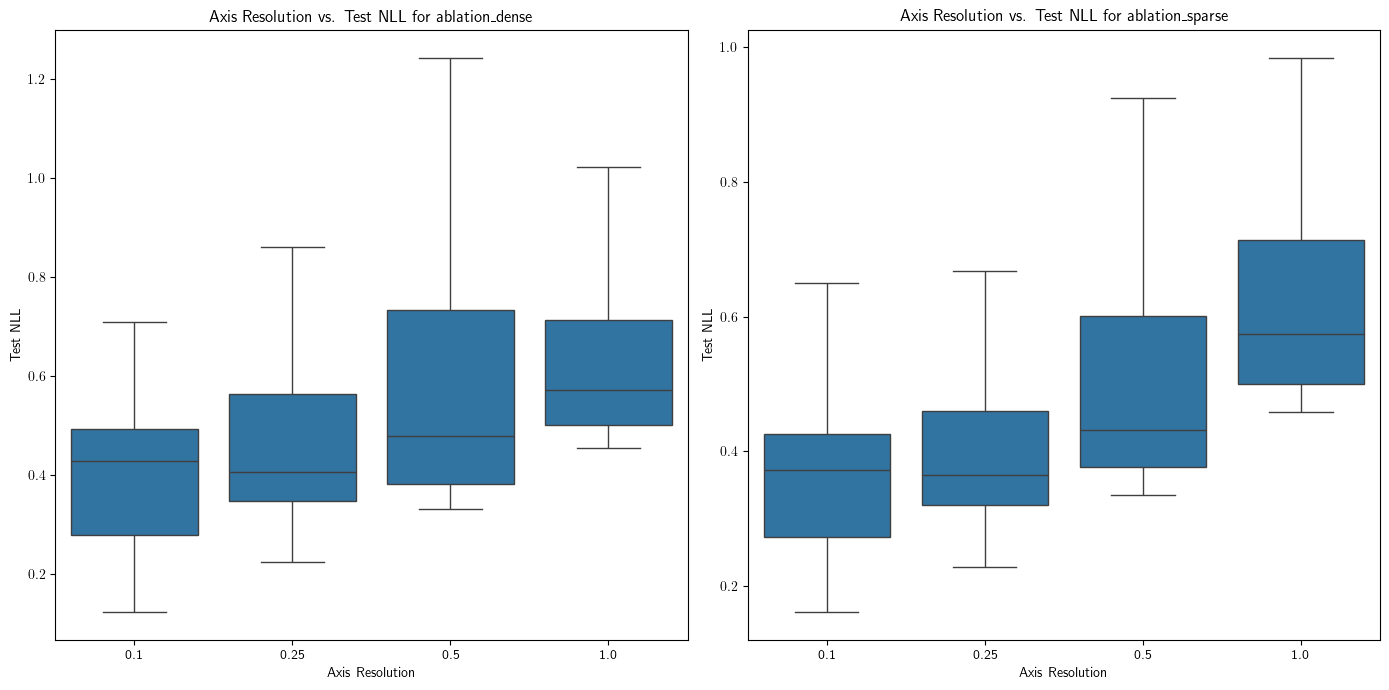

In [36]:
# create a box plot of axis resolution vs. test_nll for each dataset
num_datasets: int = len(data_frames.keys()) - 1

fig, axs = plt.subplots(1, num_datasets, figsize=(7*num_datasets, 7))

for idx, (key, df) in enumerate(data_frames.items()):
    if key == "toysim":
        continue
    sns.boxplot(x='axis_resolution', y='test_nll', data=df, ax=axs[idx], showfliers=False)
    axs[idx].set_xlabel("Axis Resolution")
    axs[idx].set_ylabel("Test NLL")
    axs[idx].set_title(f"Axis Resolution vs. Test NLL for {key}")

plt.tight_layout()
plt.savefig(f"exp2_boxplot_axis_resolution_vs_test_nll.svg")

---
### Num Tiles versus AUC and NLL
---

Text(0.5, 1.0, 'Correlation Matrix for Ablation Dense')

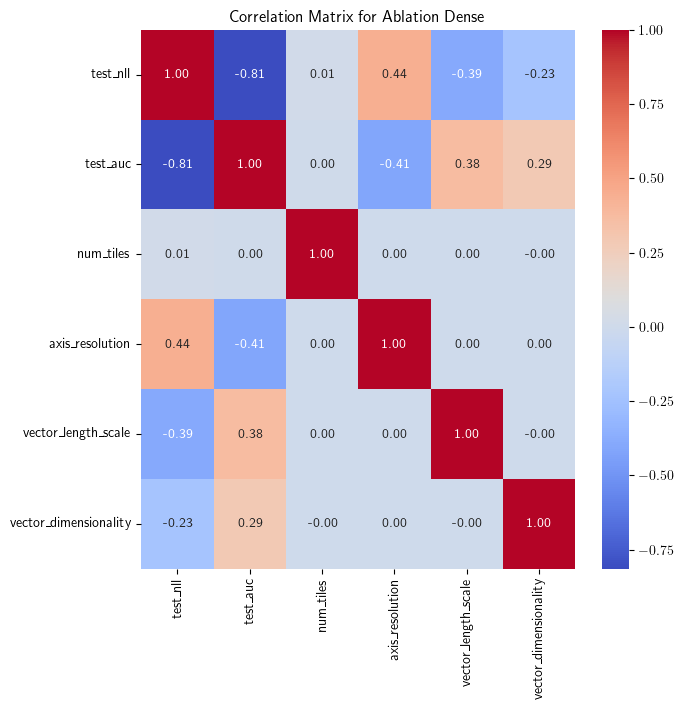

In [37]:
corr_matrix = data_frames['ablation_dense'].corr()
plt.figure(figsize=(7, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix for Ablation Dense")

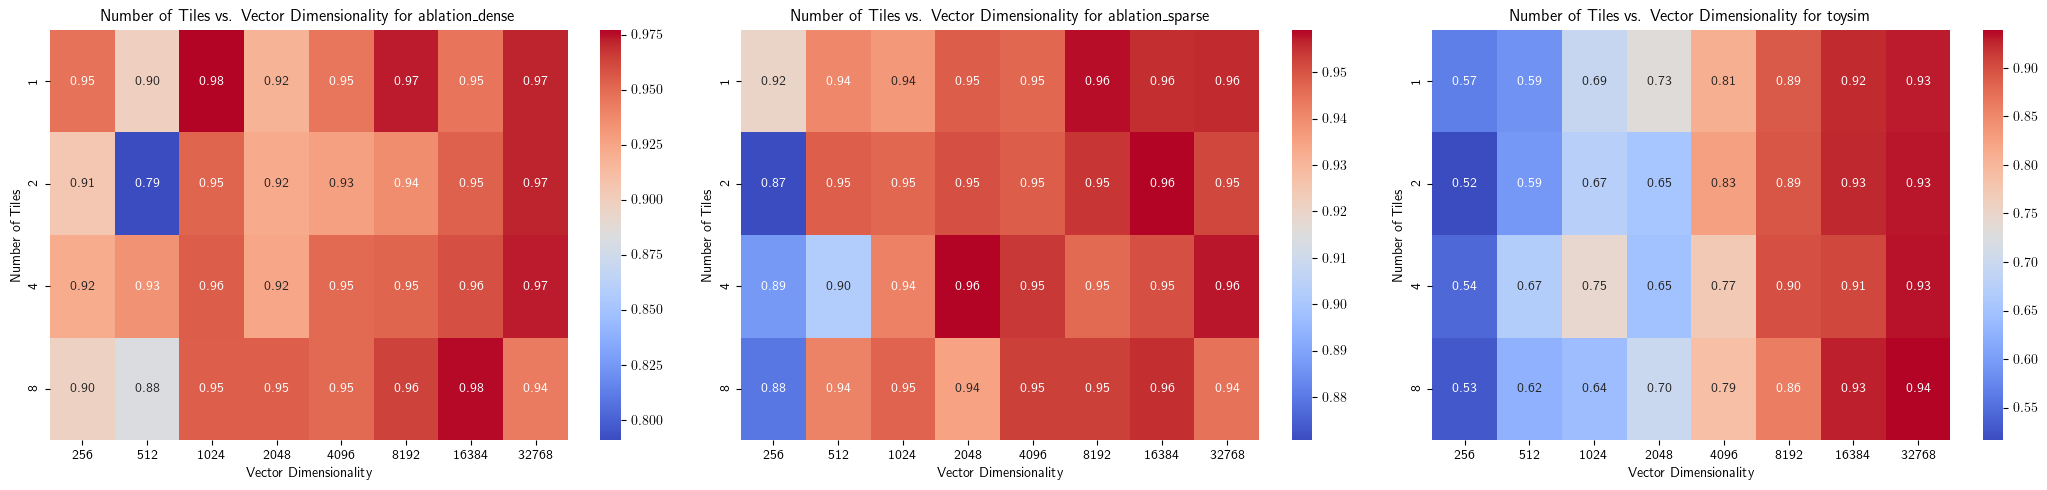

In [38]:
# pivot_df = sub_df.pivot_table(index="decoding_disk_radii_1", columns="decoding_disk_radii_2", values="test_auc")

# plt.figure(figsize=(6, 4))
# sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
# plt.title("Ablation Sparse - Entropy wrt AUC")
# plt.tight_layout()
# plt.savefig("ablation_sparse_entropy_heatmap_auc.svg")

num_datasets: int = len(data_frames.keys())

fig, axs = plt.subplots(1, num_datasets, figsize=(7*num_datasets, 5))

for idx, (key, df) in enumerate(data_frames.items()):
    if key != "toysim":
        df = df[df['axis_resolution'] == 0.1]
    df = df[df['vector_length_scale'] == 1.0]
    pivot_df = df.pivot_table(index="num_tiles", columns="vector_dimensionality", values="test_auc")
    sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm', ax=axs[idx])
    axs[idx].set_title(f"Number of Tiles vs. Vector Dimensionality for {key}")
    axs[idx].set_xlabel("Vector Dimensionality")
    axs[idx].set_ylabel("Number of Tiles")

plt.tight_layout()
plt.savefig(f"exp2_heatmap_num_tiles_vs_vector_dim.svg")

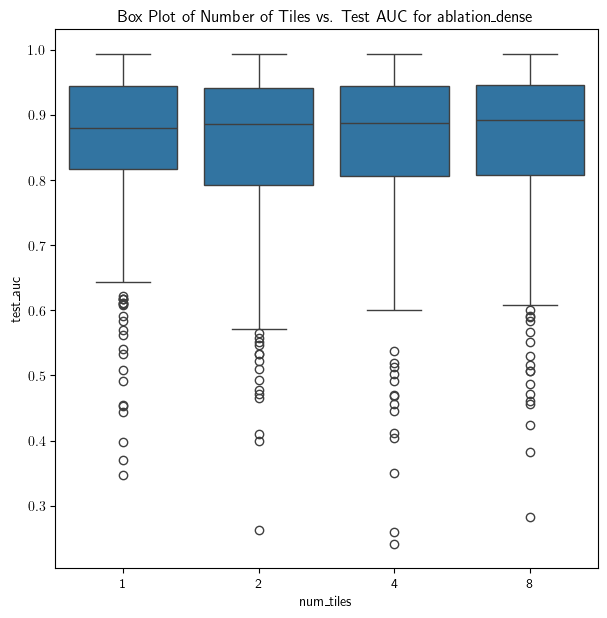

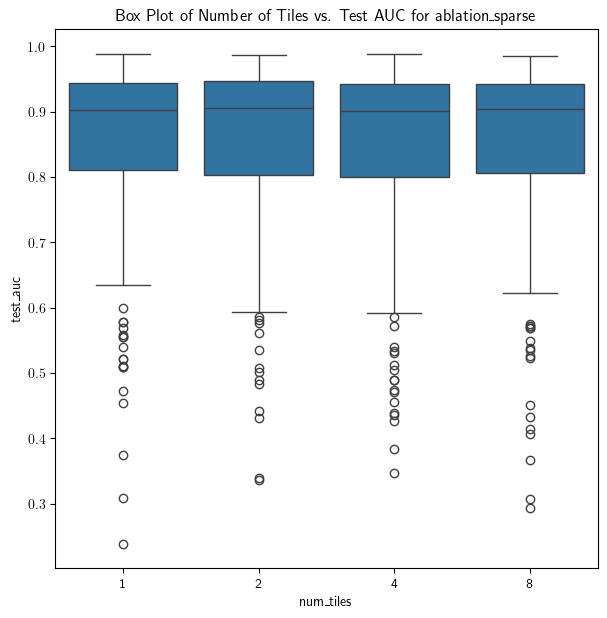

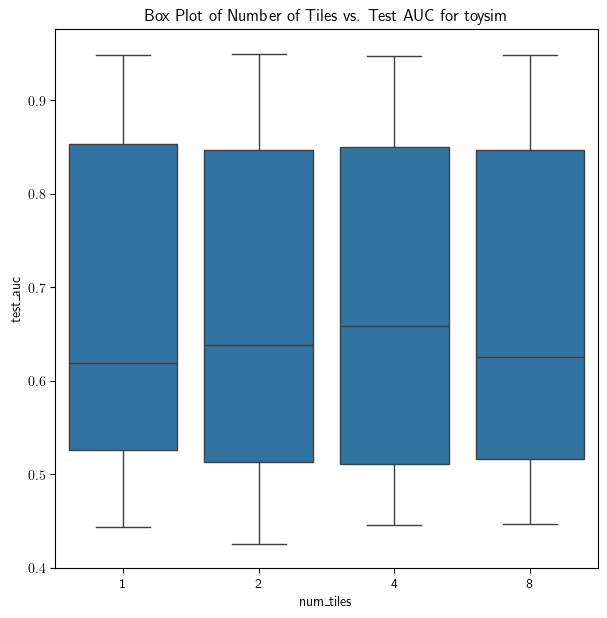

In [39]:
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    sns.boxplot(x='num_tiles', y='test_auc', data=df)
    plt.title(f"Box Plot of Number of Tiles vs. Test AUC for {key}")
    plt.savefig(f"exp2_boxplot_num_tiles_vs_test_auc_{key}.svg")

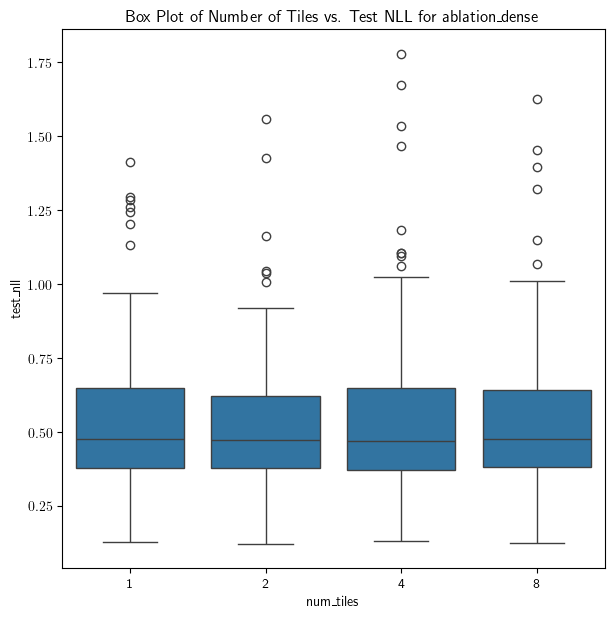

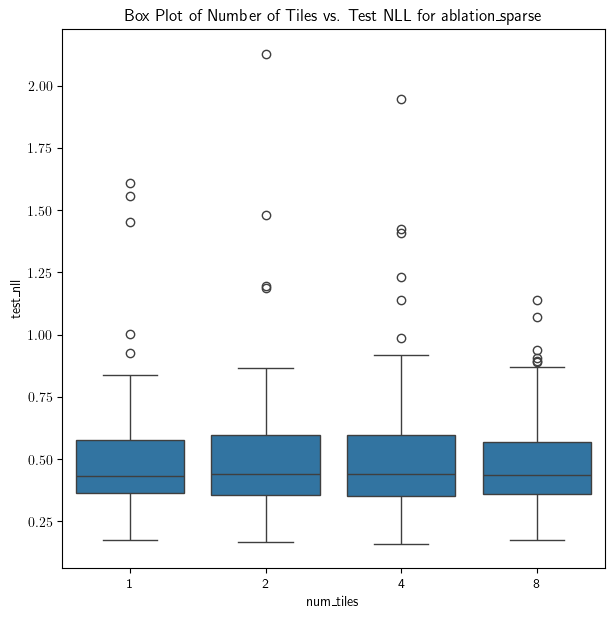

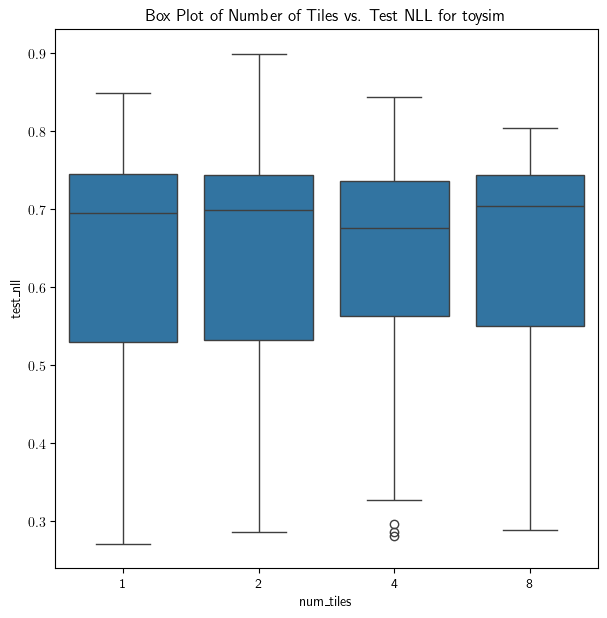

In [40]:
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    sns.boxplot(x='num_tiles', y='test_nll', data=df)
    plt.title(f"Box Plot of Number of Tiles vs. Test NLL for {key}")
    plt.savefig(f"exp2_boxplot_num_tiles_vs_test_nll_{key}.svg")